<a href="https://colab.research.google.com/github/Rigtsu/image_processing/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
image = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Поиск самого длинного отрезка

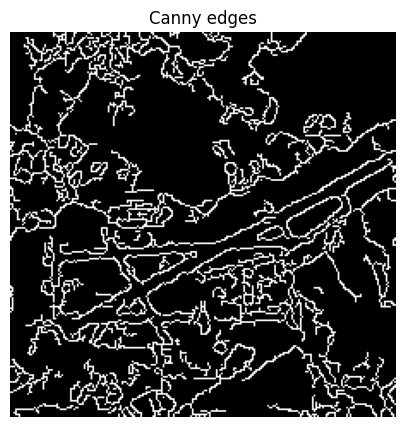

In [21]:
blur = cv2.medianBlur(gray, 5)

edges = cv2.Canny(
    blur,
    50,
    150,
    apertureSize=3
)

plt.figure(figsize=(10, 5))
plt.imshow(edges, cmap='gray')
plt.title('Canny edges')
plt.axis('off')
plt.show()

In [22]:
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=80,
    minLineLength=100,
    maxLineGap=20
)

best_len = 0
best = None

if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = l[0]

        length = np.hypot(x2 - x1, y2 - y1)

        if length > best_len:
            best_len = length
            best = (x1, y1, x2, y2)

print('Самый длинный отрезок:', best)
print(f'Длина: {best_len:.2f} пикселей')

Самый длинный отрезок: (np.int32(15), np.int32(179), np.int32(223), np.int32(69))
Длина: 235.30 пикселей


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

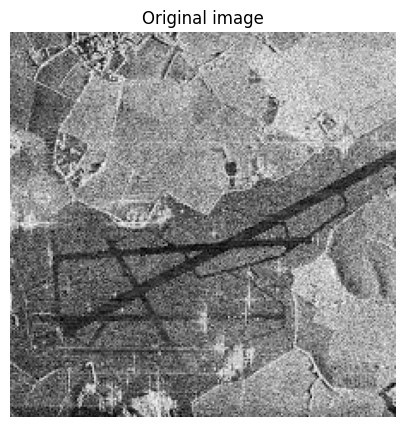

In [23]:
image_lines = image.copy()

if best is not None:
    x1, y1, x2, y2 = best

    cv2.line(
        image_lines,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2,
        cv2.LINE_AA
    )

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original image')
plt.axis('off')

Алгоритмы бинаризации

In [24]:
_, manual = cv2.threshold(
    gray, 60, 255, cv2.THRESH_BINARY
)

_, otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

_, tri = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE
)

adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    101,
    45
)

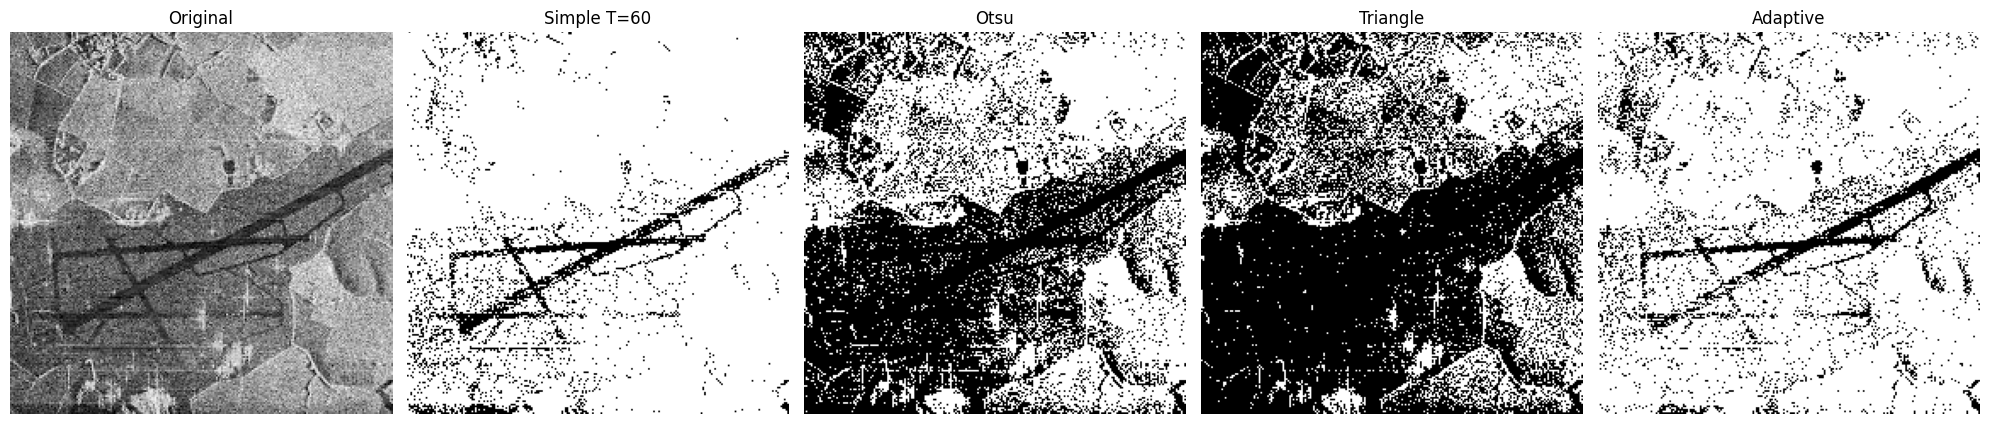

In [25]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5))

images = [
    (gray, 'Original'),
    (manual, 'Simple T=60'),
    (otsu, 'Otsu'),
    (tri, 'Triangle'),
    (adaptive, 'Adaptive')
]

for a, (img, title) in zip(ax, images):
    a.imshow(img, cmap='gray')
    a.set_title(title)
    a.axis('off')

plt.tight_layout()
plt.show()

In [26]:
for name, bw in [
    ('Simple', manual),
    ('Otsu', otsu),
    ('Triangle', tri),
    ('Adaptive', adaptive)
]:
    white_fraction = np.mean(bw > 0)

    print(
        f'{name}: white fraction = {white_fraction:.3f}'
    )

Simple: white fraction = 0.911
Otsu: white fraction = 0.514
Triangle: white fraction = 0.335
Adaptive: white fraction = 0.864


выделение полос движения

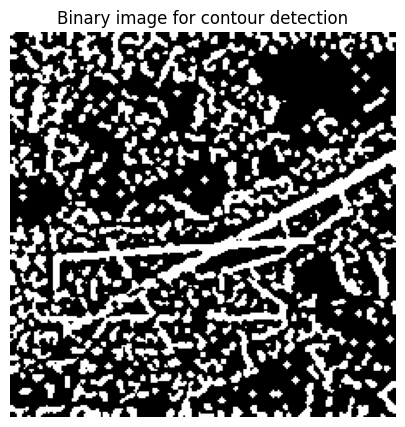

In [27]:
blurred = cv2.GaussianBlur(
    adaptive,
    (7, 7),
    0
)

thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

plt.figure(figsize=(10, 5))
plt.imshow(thresh, cmap='gray')
plt.title('Binary image for contour detection')
plt.axis('off')
plt.show()

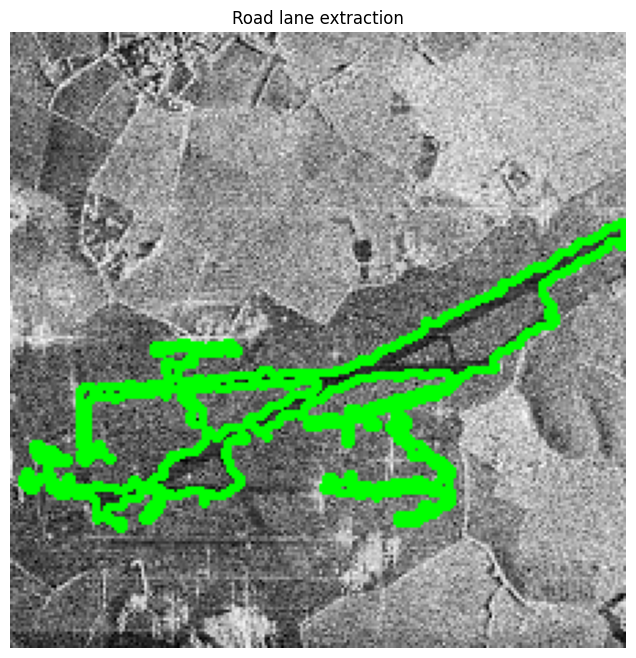

In [28]:
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

lane_image = image.copy()

for c in contours:
    area = cv2.contourArea(c)

    if area > 500:
        cv2.drawContours(
            lane_image,
            [c],
            -1,
            (0, 255, 0),
            2
        )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB))
plt.title('Road lane extraction')
plt.axis('off')
plt.show()